In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
from datasets import load_dataset

ds = load_dataset("Hello-SimpleAI/HC3", "all")

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

dataset = load_dataset("Hello-SimpleAI/HC3", name="all")

print(dataset)

In [ ]:
!pip install -q datasets==2.14.6 huggingface_hub==0.17.3

In [ ]:

from datasets import load_dataset

dataset = load_dataset("Hello-SimpleAI/HC3", name="all")

print(dataset)


In [ ]:
!pip install -q transformers datasets bert-score textstat scipy scikit-learn accelerate sentencepiece

In [ ]:
import os, json, random, warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    GPT2LMHeadModel, GPT2Tokenizer
)
from datasets import load_dataset
from bert_score import score as bert_score_fn
import textstat

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

In [ ]:
# Fix the huggingface_hub / transformers version conflict first
!pip install -q "huggingface_hub==0.23.4"
!pip install -q "transformers==4.41.2"
!pip install -q "datasets==2.19.2"
!pip install -q bert-score textstat scipy scikit-learn accelerate sentencepiece

# Restart kernel after this cell
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

In [ ]:
import os, json, random, warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    GPT2LMHeadModel, GPT2Tokenizer
)
from datasets import load_dataset
from bert_score import score as bert_score_fn
import textstat

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print('All imports successful!')

In [ ]:
# Loads directly from HuggingFace — make sure Internet is ON in Kaggle settings
ds = load_dataset('Hello-SimpleAI/HC3', 'all', split='train')
raw_df = ds.to_pandas()
print(f'Loaded {len(raw_df)} rows | Columns: {raw_df.columns.tolist()}')
raw_df.head(2)

In [ ]:
rows = []
for _, row in raw_df.iterrows():
    q = row['question']
    for ans in row['human_answers']:
        if ans and len(ans.strip()) > 50:
            rows.append({'question': q, 'answer': ans.strip(), 'label': 0})
    for ans in row['chatgpt_answers']:
        if ans and len(ans.strip()) > 50:
            rows.append({'question': q, 'answer': ans.strip(), 'label': 1})

df = pd.DataFrame(rows)
print(f"Human: {(df.label==0).sum()} | ChatGPT: {(df.label==1).sum()}")

N = 500
human_df = df[df.label==0].sample(N, random_state=SEED).reset_index(drop=True)
ai_df    = df[df.label==1].sample(N, random_state=SEED).reset_index(drop=True)
print(f'Working with {N} human + {N} AI samples')

In [ ]:
# Surrogate detector
DETECTOR = 'roberta-base-openai-detector'
det_tok = AutoTokenizer.from_pretrained(DETECTOR)
det_model = AutoModelForSequenceClassification.from_pretrained(DETECTOR).to(DEVICE)
det_model.eval()
print('Detector loaded:', DETECTOR)

# GPT-2 for perplexity + generation
gpt2_tok = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_tok.pad_token = gpt2_tok.eos_token
gpt2_lm = GPT2LMHeadModel.from_pretrained('gpt2').to(DEVICE)
gpt2_lm.eval()
print('GPT-2 loaded')

In [ ]:
# ── AI detection score ──────────────────────────────────────────────────────
def get_ai_score(text):
    """Returns P(AI-generated) in [0,1]. Higher = more AI-like."""
    inputs = det_tok(text, return_tensors='pt', truncation=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        logits = det_model(**inputs).logits
    return torch.softmax(logits, dim=-1)[0][1].item()


# ── Perplexity (GPT-2) ───────────────────────────────────────────────────────
def compute_perplexity(text):
    """Lower = more fluent."""
    enc = gpt2_tok(text, return_tensors='pt', truncation=True, max_length=512)
    ids = enc.input_ids.to(DEVICE)
    with torch.no_grad():
        loss = gpt2_lm(ids, labels=ids).loss
    return torch.exp(loss).item()


# ── BERTScore ────────────────────────────────────────────────────────────────
def compute_bertscore(candidates, references):
    """Returns mean F1 BERTScore."""
    _, _, F1 = bert_score_fn(
        candidates, references,
        lang='en', model_type='distilbert-base-uncased', verbose=False
    )
    return F1.mean().item()


# ── Flesch-Kincaid Grade ─────────────────────────────────────────────────────
def compute_fk_grade(text):
    return textstat.flesch_kincaid_grade(text)


# ── Stylometric Feature Extraction ───────────────────────────────────────────
def extract_stylometrics(text):
    words = text.lower().split()
    wc = max(len(words), 1)
    sents = [s.strip() for s in text.replace('!','.').replace('?','.').split('.') if s.strip()]
    sent_lens = [len(s.split()) for s in sents] or [0]

    contractions = ["n't","'re","'ve","'ll","'d","'m","'s"]
    hedges = ['maybe','perhaps','might','could','possibly','probably',
              'seems','appears','likely','generally','often','sometimes']
    func_words = {'the','a','an','is','are','was','were','be','been','being',
                  'have','has','had','do','does','did','will','would','could',
                  'should','may','might','shall','can','and','but','or','in',
                  'on','at','to','of','with','by','from','as','into'}

    return {
        'contraction_rate': sum(text.count(c) for c in contractions) / wc,
        'hedging_density':  sum(words.count(h) for h in hedges) / wc,
        'length_variance':  float(np.var(sent_lens)),
        'ttr':              len(set(words)) / wc,
        'avg_sent_len':     float(np.mean(sent_lens)),
        'func_ratio':       sum(1 for w in words if w in func_words) / wc
    }


# ── Persona Alignment (KL-divergence) ────────────────────────────────────────
def persona_alignment_score(text_features, persona):
    """Returns (alignment_score, kl_div). Higher alignment = more human-like."""
    keys = ['contraction_rate', 'hedging_density', 'ttr', 'func_ratio']
    eps = 1e-8
    p = np.array([max(text_features[k], eps) for k in keys])
    q = np.array([max(persona[k], eps)       for k in keys])
    p /= p.sum(); q /= q.sum()
    kl  = float(scipy_entropy(p, q))
    return float(np.exp(-kl)), kl

print('All metric functions ready.')

In [ ]:
print('Extracting persona from human samples...')
feat_list = [extract_stylometrics(t) for t in tqdm(human_df['answer'].tolist())]

persona_profile = {k: float(np.mean([f[k] for f in feat_list])) for k in feat_list[0]}

print('\nHuman Persona Profile:')
for k, v in persona_profile.items():
    print(f'  {k:25s}: {v:.4f}')

In [ ]:
N_POOL = 200
K_SHOTS = 3

print(f'Ranking {len(human_df)} human samples by persona alignment...')
pool_rows = []
for _, row in tqdm(human_df.iterrows(), total=len(human_df)):
    feats = extract_stylometrics(row['answer'])
    alignment, kl = persona_alignment_score(feats, persona_profile)
    pool_rows.append({**row, 'alignment': alignment, 'kl_div': kl})

pool_df = (pd.DataFrame(pool_rows)
           .sort_values('alignment', ascending=False)
           .head(N_POOL)
           .reset_index(drop=True))

print(f'Pool built. Mean alignment: {pool_df.alignment.mean():.4f}')
pool_df[['question','alignment','kl_div']].head(5)

In [ ]:
def build_persona_prompt(ai_text, question, pool, k=K_SHOTS):
    examples = pool.sample(min(k, len(pool)), random_state=SEED)
    
    desc = (
        f"Write like a human who uses contractions {persona_profile['contraction_rate']:.1%} of the time, "
        f"hedges with words like 'maybe'/'probably' ({persona_profile['hedging_density']:.1%} rate), "
        f"varies sentence lengths, and keeps a casual conversational tone."
    )

    prompt = f"You are rewriting AI-generated text to sound more human.\nPersona: {desc}\nPreserve all original meaning. Do not add new facts.\n\nHuman-written examples:\n"
    for _, ex in examples.iterrows():
        prompt += f"Q: {ex['question'][:100]}\nA: {ex['answer'][:250]}\n\n"
    prompt += f"Now rewrite this AI answer in the human style above:\nQ: {question[:150]}\nAI Answer: {ai_text[:400]}\nHuman Rewrite:"
    return prompt


# Test it
sample = ai_df.iloc[0]
print(build_persona_prompt(sample['answer'], sample['question'], pool_df)[:600])
print('...')

In [ ]:
def generate_rewrite(prompt, temperature=0.85, top_p=0.92, max_new_tokens=180):
    inputs = gpt2_tok(prompt, return_tensors='pt', truncation=True, max_length=768).to(DEVICE)
    input_len = inputs['input_ids'].shape[1]
    with torch.no_grad():
        out = gpt2_lm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=1.2,
            pad_token_id=gpt2_tok.eos_token_id,
            eos_token_id=gpt2_tok.eos_token_id
        )
    text = gpt2_tok.decode(out[0][input_len:], skip_special_tokens=True)
    text = text.strip().split('\n')[0].strip()
    return text if len(text) > 30 else None

In [ ]:
def compute_combined_loss(original, candidate, lam=0.5, beta=0.3, gamma=0.2):
    if not candidate or len(candidate.strip()) < 20:
        return float('inf'), {}

    # L_adv: adversarial loss — P(AI | candidate)
    ai_score = get_ai_score(candidate)
    L_adv = ai_score

    # L_sem: semantic loss — word overlap proxy (fast; BERTScore used in final eval)
    orig_w = set(original.lower().split())
    cand_w = set(candidate.lower().split())
    L_sem = 1.0 - len(orig_w & cand_w) / max(len(orig_w), 1)

    # L_persona: KL-divergence from human persona
    feats = extract_stylometrics(candidate)
    alignment, kl = persona_alignment_score(feats, persona_profile)
    L_persona = min(kl, 5.0)

    combined = lam * L_adv + beta * L_sem + gamma * L_persona
    return combined, {
        'L_adv': L_adv, 'L_sem': L_sem, 'L_persona': L_persona,
        'combined': combined, 'ai_score': ai_score, 'alignment': alignment
    }

In [ ]:
def our_method(ai_text, question, pool, n_candidates=5, lam=0.5, beta=0.3, gamma=0.2):
    """
    Stylistic Persona-Augmented Prompt Optimizer.
    Generates n_candidates with varied temperatures, picks the one with lowest combined loss.
    """
    prompt = build_persona_prompt(ai_text, question, pool)
    temperatures = [0.7, 0.8, 0.9, 1.0, 1.1][:n_candidates]

    candidates = []
    for temp in temperatures:
        cand = generate_rewrite(prompt, temperature=temp)
        if cand:
            loss, metrics = compute_combined_loss(ai_text, cand, lam, beta, gamma)
            candidates.append({'text': cand, 'loss': loss, 'metrics': metrics})

    if not candidates:
        return ai_text, {}

    best = min(candidates, key=lambda x: x['loss'])
    return best['text'], best['metrics']

In [ ]:
def sico_baseline(ai_text, question, pool, n_candidates=3):
    """SICO: no persona, pure adversarial, static pool."""
    examples = pool.sample(min(3, len(pool)), random_state=SEED)
    prompt = "Rewrite the following text to sound more natural:\n\n"
    for _, ex in examples.iterrows():
        prompt += f"Example: {ex['answer'][:200]}\n\n"
    prompt += f"Rewrite: {ai_text[:400]}\nResult:"

    best_text, best_score = ai_text, get_ai_score(ai_text)
    for temp in [0.7, 0.9, 1.1][:n_candidates]:
        cand = generate_rewrite(prompt, temperature=temp)
        if cand:
            score = get_ai_score(cand)
            if score < best_score:
                best_score, best_text = score, cand
    return best_text, {'ai_score': best_score}


def sda_baseline(ai_text, question, pool, n_candidates=3):
    """SDA: retrieval-based context, no stylometric modeling."""
    examples = pool.sample(min(5, len(pool)), random_state=SEED+1)
    prompt = f"Question: {question[:100]}\nHuman answers for context:\n"
    for _, ex in examples.iterrows():
        prompt += f"- {ex['answer'][:200]}\n"
    prompt += f"\nRewrite this to be more human-like:\n{ai_text[:400]}\nResponse:"

    best_text, best_score = ai_text, get_ai_score(ai_text)
    for temp in [0.8, 0.95, 1.05][:n_candidates]:
        cand = generate_rewrite(prompt, temperature=temp)
        if cand:
            score = get_ai_score(cand)
            if score < best_score:
                best_score, best_text = score, cand
    return best_text, {'ai_score': best_score}

print('Baselines defined.')

In [ ]:
N_EVAL = 50       # Increase to 200 for final results
THRESHOLD = 0.5   # AI score > 0.5 → classified as AI

eval_set = ai_df.head(N_EVAL).reset_index(drop=True)
results = {m: [] for m in ['original', 'ours', 'sico', 'sda']}

print(f'Evaluating {N_EVAL} samples across 4 methods...')

for _, row in tqdm(eval_set.iterrows(), total=N_EVAL):
    ai_text  = row['answer']
    question = row['question']

    def record(text, original=None):
        ai_s = get_ai_score(text)
        feats = extract_stylometrics(text)
        align, kl = persona_alignment_score(feats, persona_profile)
        return {
            'text': text, 'original': original or text,
            'ai_score': ai_s, 'evaded': ai_s < THRESHOLD,
            'ppl': compute_perplexity(text),
            'fk_grade': compute_fk_grade(text),
            'persona_alignment': align, 'kl_div': kl
        }

    results['original'].append(record(ai_text))

    our_txt,  _  = our_method(ai_text, question, pool_df, n_candidates=3)
    sico_txt, _  = sico_baseline(ai_text, question, pool_df)
    sda_txt,  _  = sda_baseline(ai_text, question, pool_df)

    results['ours'].append(record(our_txt,  original=ai_text))
    results['sico'].append(record(sico_txt, original=ai_text))
    results['sda'].append( record(sda_txt,  original=ai_text))

print('Done!')

In [ ]:
# Kaggle P100 uses CUDA 11.8 — reinstall torch to match
!pip install -q torch==2.1.0 torchvision==0.16.0 --index-url https://download.pytorch.org/whl/cu118
!pip install -q "huggingface_hub==0.23.4" "transformers==4.41.2" "datasets==2.19.2"
!pip install -q bert-score textstat scipy scikit-learn accelerate sentencepiece

# Restart kernel after this — mandatory
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

In [ ]:
import subprocess

print("=== CUDA Version ===")
print(subprocess.getoutput("nvcc --version"))

print("\n=== nvidia-smi ===")
print(subprocess.getoutput("nvidia-smi"))

print("\n=== Current PyTorch ===")
import torch
print(f"torch version : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version  : {torch.version.cuda}")
    print(f"GPU name      : {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available to torch")

In [ ]:
!pip install torch==2.4.1 torchvision==0.19.1 --index-url https://download.pytorch.org/whl/cu124 --force-reinstall --quiet
!pip install "huggingface_hub==0.23.4" "transformers==4.41.2" "datasets==2.19.2" --quiet
!pip install bert-score textstat scipy scikit-learn accelerate sentencepiece --quiet

import IPython
IPython.Application.instance().kernel.do_shutdown(True)

In [1]:
import torch
print(f"torch        : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version : {torch.version.cuda}")
print(f"GPU          : {torch.cuda.get_device_name(0)}")

# Must print True and show cuda:0
x = torch.ones(3, 3).cuda()
print(f"Tensor device: {x.device}  ✓")
```

Expected output:
```
torch        : 2.4.1+cu124
CUDA available: True
CUDA version : 12.4
GPU          : Tesla P100-PCIE-16GB
Tensor device: cuda:0  ✓

SyntaxError: invalid decimal literal (4282072277.py, line 17)

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

x = torch.ones(3, 3).cuda()
print(f"Tensor device: {x.device}")

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

x = torch.ones(3, 3).cuda()
print(f"Tensor device: {x.device}")

In [3]:
!pip install "huggingface_hub==0.26.2" --quiet
!pip install "transformers==4.44.2" --quiet  
!pip install "datasets==2.21.0" --quiet
!pip install bert-score textstat scipy scikit-learn accelerate sentencepiece --quiet

In [4]:
import os, json, random, warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    GPT2LMHeadModel, GPT2Tokenizer
)
from datasets import load_dataset
from bert_score import score as bert_score_fn
import textstat

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"torch   : {torch.__version__}")
print(f"device  : {DEVICE}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none'}")
print("Imports OK")

torch   : 2.10.0+cu128
device  : cuda
GPU     : Tesla P100-PCIE-16GB
Imports OK


In [5]:
ds = load_dataset('Hello-SimpleAI/HC3', 'all', split='train')
raw_df = ds.to_pandas()
print(f'Loaded {len(raw_df)} rows')
raw_df.head(2)

Loaded 24322 rows


,id,question,human_answers,chatgpt_answers,source
0,0,"Why is every book I hear about a "" NY Times # ...","[Basically there are many categories of "" Best...",[There are many different best seller lists th...,reddit_eli5
1,1,"If salt is so bad for cars , why do we use it ...",[salt is good for not dying in car crashes and...,[Salt is used on roads to help melt ice and sn...,reddit_eli5


In [6]:
rows = []
for _, row in raw_df.iterrows():
    q = row['question']
    for ans in row['human_answers']:
        if ans and len(ans.strip()) > 50:
            rows.append({'question': q, 'answer': ans.strip(), 'label': 0})
    for ans in row['chatgpt_answers']:
        if ans and len(ans.strip()) > 50:
            rows.append({'question': q, 'answer': ans.strip(), 'label': 1})

df = pd.DataFrame(rows)
print(f"Human: {(df.label==0).sum()} | ChatGPT: {(df.label==1).sum()}")

N = 500
human_df = df[df.label==0].sample(N, random_state=SEED).reset_index(drop=True)
ai_df    = df[df.label==1].sample(N, random_state=SEED).reset_index(drop=True)
print(f'Working with {N} human + {N} AI samples')

Human: 57552 | ChatGPT: 26839
Working with 500 human + 500 AI samples


In [7]:
DETECTOR = 'roberta-base-openai-detector'
det_tok   = AutoTokenizer.from_pretrained(DETECTOR)
det_model = AutoModelForSequenceClassification.from_pretrained(
    DETECTOR, torch_dtype=torch.float32
).to(DEVICE)
det_model.eval()
print('Detector loaded on:', next(det_model.parameters()).device)

gpt2_tok = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_tok.pad_token = gpt2_tok.eos_token
gpt2_lm  = GPT2LMHeadModel.from_pretrained(
    'gpt2', torch_dtype=torch.float32
).to(DEVICE)
gpt2_lm.eval()
print('GPT-2 loaded on:', next(gpt2_lm.parameters()).device)

Some weights of the model checkpoint at roberta-base-openai-detector were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Detector loaded on: cuda:0
GPT-2 loaded on: cuda:0


In [8]:
def get_ai_score(text):
    inputs = det_tok(text, return_tensors='pt', truncation=True, max_length=512)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        logits = det_model(**inputs).logits
    return torch.softmax(logits.float(), dim=-1)[0][1].item()

def compute_perplexity(text):
    enc = gpt2_tok(text, return_tensors='pt', truncation=True, max_length=512)
    ids = enc.input_ids.to(DEVICE)
    with torch.no_grad():
        loss = gpt2_lm(ids, labels=ids).loss
    return torch.exp(loss.float()).item()

def compute_bertscore(candidates, references):
    _, _, F1 = bert_score_fn(
        candidates, references,
        lang='en', model_type='distilbert-base-uncased', verbose=False
    )
    return F1.mean().item()

def compute_fk_grade(text):
    return textstat.flesch_kincaid_grade(text)

def extract_stylometrics(text):
    words = text.lower().split()
    wc = max(len(words), 1)
    sents = [s.strip() for s in text.replace('!','.').replace('?','.').split('.') if s.strip()]
    sent_lens = [len(s.split()) for s in sents] or [0]

    contractions = ["n't","'re","'ve","'ll","'d","'m","'s"]
    hedges = ['maybe','perhaps','might','could','possibly','probably',
              'seems','appears','likely','generally','often','sometimes']
    func_words = {'the','a','an','is','are','was','were','be','been','being',
                  'have','has','had','do','does','did','will','would','could',
                  'should','may','might','shall','can','and','but','or','in',
                  'on','at','to','of','with','by','from','as','into'}
    return {
        'contraction_rate': sum(text.count(c) for c in contractions) / wc,
        'hedging_density':  sum(words.count(h) for h in hedges) / wc,
        'length_variance':  float(np.var(sent_lens)),
        'ttr':              len(set(words)) / wc,
        'avg_sent_len':     float(np.mean(sent_lens)),
        'func_ratio':       sum(1 for w in words if w in func_words) / wc
    }

def persona_alignment_score(text_features, persona):
    keys = ['contraction_rate', 'hedging_density', 'ttr', 'func_ratio']
    eps = 1e-8
    p = np.array([max(text_features[k], eps) for k in keys])
    q = np.array([max(persona[k], eps)       for k in keys])
    p /= p.sum(); q /= q.sum()
    kl = float(scipy_entropy(p, q))
    return float(np.exp(-kl)), kl

print('All metric functions ready.')

All metric functions ready.


In [9]:
print('Extracting persona...')
feat_list = [extract_stylometrics(t) for t in tqdm(human_df['answer'].tolist())]
persona_profile = {k: float(np.mean([f[k] for f in feat_list])) for k in feat_list[0]}
print('Human Persona Profile:')
for k, v in persona_profile.items():
    print(f'  {k:25s}: {v:.4f}')

Extracting persona...


100%|██████████| 500/500 [00:00<00:00, 8685.48it/s]

Human Persona Profile:
  contraction_rate         : 0.0186
  hedging_density          : 0.0048
  length_variance          : 93.3577
  ttr                      : 0.7015
  avg_sent_len             : 19.4348
  func_ratio               : 0.2476


In [10]:
N_POOL = 200
K_SHOTS = 3
pool_rows = []
for _, row in tqdm(human_df.iterrows(), total=len(human_df)):
    feats = extract_stylometrics(row['answer'])
    alignment, kl = persona_alignment_score(feats, persona_profile)
    pool_rows.append({**row, 'alignment': alignment, 'kl_div': kl})

pool_df = (pd.DataFrame(pool_rows)
           .sort_values('alignment', ascending=False)
           .head(N_POOL)
           .reset_index(drop=True))
print(f'Pool built. Mean alignment: {pool_df.alignment.mean():.4f}')

100%|██████████| 500/500 [00:00<00:00, 1436.43it/s]

Pool built. Mean alignment: 0.9888


In [11]:
def build_persona_prompt(ai_text, question, pool, k=K_SHOTS):
    examples = pool.sample(min(k, len(pool)), random_state=SEED)
    desc = (
        f"Write like a human who uses contractions {persona_profile['contraction_rate']:.1%} of the time, "
        f"hedges with words like 'maybe'/'probably' ({persona_profile['hedging_density']:.1%} rate), "
        f"varies sentence lengths, and keeps a casual conversational tone."
    )
    prompt = f"You are rewriting AI-generated text to sound more human.\nPersona: {desc}\nPreserve all original meaning. Do not add new facts.\n\nHuman-written examples:\n"
    for _, ex in examples.iterrows():
        prompt += f"Q: {ex['question'][:100]}\nA: {ex['answer'][:250]}\n\n"
    prompt += f"Now rewrite this AI answer in the human style above:\nQ: {question[:150]}\nAI Answer: {ai_text[:400]}\nHuman Rewrite:"
    return prompt

In [12]:
def generate_rewrite(prompt, temperature=0.85, top_p=0.92, max_new_tokens=180):
    inputs = gpt2_tok(prompt, return_tensors='pt', truncation=True, max_length=768)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    input_len = inputs['input_ids'].shape[1]
    with torch.no_grad():
        out = gpt2_lm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=1.2,
            pad_token_id=gpt2_tok.eos_token_id,
            eos_token_id=gpt2_tok.eos_token_id
        )
    text = gpt2_tok.decode(out[0][input_len:], skip_special_tokens=True)
    text = text.strip().split('\n')[0].strip()
    return text if len(text) > 30 else None

In [13]:
def compute_combined_loss(original, candidate, lam=0.5, beta=0.3, gamma=0.2):
    if not candidate or len(candidate.strip()) < 20:
        return float('inf'), {}
    ai_score  = get_ai_score(candidate)
    L_adv     = ai_score
    orig_w    = set(original.lower().split())
    cand_w    = set(candidate.lower().split())
    L_sem     = 1.0 - len(orig_w & cand_w) / max(len(orig_w), 1)
    feats     = extract_stylometrics(candidate)
    alignment, kl = persona_alignment_score(feats, persona_profile)
    L_persona = min(kl, 5.0)
    combined  = lam * L_adv + beta * L_sem + gamma * L_persona
    return combined, {
        'L_adv': L_adv, 'L_sem': L_sem, 'L_persona': L_persona,
        'combined': combined, 'ai_score': ai_score, 'alignment': alignment
    }

In [14]:
def our_method(ai_text, question, pool, n_candidates=5, lam=0.5, beta=0.3, gamma=0.2):
    prompt = build_persona_prompt(ai_text, question, pool)
    temperatures = [0.7, 0.8, 0.9, 1.0, 1.1][:n_candidates]
    candidates = []
    for temp in temperatures:
        cand = generate_rewrite(prompt, temperature=temp)
        if cand:
            loss, metrics = compute_combined_loss(ai_text, cand, lam, beta, gamma)
            candidates.append({'text': cand, 'loss': loss, 'metrics': metrics})
    if not candidates:
        return ai_text, {}
    best = min(candidates, key=lambda x: x['loss'])
    return best['text'], best['metrics']

def sico_baseline(ai_text, question, pool, n_candidates=3):
    examples = pool.sample(min(3, len(pool)), random_state=SEED)
    prompt = "Rewrite the following text to sound more natural:\n\n"
    for _, ex in examples.iterrows():
        prompt += f"Example: {ex['answer'][:200]}\n\n"
    prompt += f"Rewrite: {ai_text[:400]}\nResult:"
    best_text, best_score = ai_text, get_ai_score(ai_text)
    for temp in [0.7, 0.9, 1.1][:n_candidates]:
        cand = generate_rewrite(prompt, temperature=temp)
        if cand:
            score = get_ai_score(cand)
            if score < best_score:
                best_score, best_text = score, cand
    return best_text, {'ai_score': best_score}

def sda_baseline(ai_text, question, pool, n_candidates=3):
    examples = pool.sample(min(5, len(pool)), random_state=SEED+1)
    prompt = f"Question: {question[:100]}\nHuman answers for context:\n"
    for _, ex in examples.iterrows():
        prompt += f"- {ex['answer'][:200]}\n"
    prompt += f"\nRewrite this to be more human-like:\n{ai_text[:400]}\nResponse:"
    best_text, best_score = ai_text, get_ai_score(ai_text)
    for temp in [0.8, 0.95, 1.05][:n_candidates]:
        cand = generate_rewrite(prompt, temperature=temp)
        if cand:
            score = get_ai_score(cand)
            if score < best_score:
                best_score, best_text = score, cand
    return best_text, {'ai_score': best_score}

print('All methods defined.')

All methods defined.


In [15]:
N_EVAL = 50
THRESHOLD = 0.5
eval_set = ai_df.head(N_EVAL).reset_index(drop=True)
results = {m: [] for m in ['original', 'ours', 'sico', 'sda']}

print(f'Evaluating {N_EVAL} samples across 4 methods...')

for _, row in tqdm(eval_set.iterrows(), total=N_EVAL):
    ai_text  = row['answer']
    question = row['question']

    def record(text, original=None):
        ai_s = get_ai_score(text)
        feats = extract_stylometrics(text)
        align, kl = persona_alignment_score(feats, persona_profile)
        return {
            'text': text, 'original': original or text,
            'ai_score': ai_s, 'evaded': ai_s < THRESHOLD,
            'ppl': compute_perplexity(text),
            'fk_grade': compute_fk_grade(text),
            'persona_alignment': align, 'kl_div': kl
        }

    results['original'].append(record(ai_text))
    our_txt,  _ = our_method(ai_text, question, pool_df, n_candidates=3)
    sico_txt, _ = sico_baseline(ai_text, question, pool_df)
    sda_txt,  _ = sda_baseline(ai_text, question, pool_df)
    results['ours'].append(record(our_txt,  original=ai_text))
    results['sico'].append(record(sico_txt, original=ai_text))
    results['sda'].append( record(sda_txt,  original=ai_text))

print('Done!')

Evaluating 50 samples across 4 methods...


  0%|          | 0/50 [00:00<?, ?it/s]


AcceleratorError: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [16]:
# Detector runs on CPU to avoid CUDA sm_60 incompatibility with torch 2.10+cu128
# GPT-2 also on CPU — P100 kernel image unavailable for this torch build
DET_DEVICE = 'cpu'
GEN_DEVICE = 'cpu'

DETECTOR = 'roberta-base-openai-detector'
det_tok   = AutoTokenizer.from_pretrained(DETECTOR)
det_model = AutoModelForSequenceClassification.from_pretrained(
    DETECTOR, torch_dtype=torch.float32
).to(DET_DEVICE)
det_model.eval()
print('Detector loaded on:', DET_DEVICE)

gpt2_tok = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_tok.pad_token = gpt2_tok.eos_token
gpt2_lm  = GPT2LMHeadModel.from_pretrained(
    'gpt2', torch_dtype=torch.float32
).to(GEN_DEVICE)
gpt2_lm.eval()
print('GPT-2 loaded on:', GEN_DEVICE)

Some weights of the model checkpoint at roberta-base-openai-detector were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Detector loaded on: cpu
GPT-2 loaded on: cpu


In [17]:
def get_ai_score(text):
    inputs = det_tok(text, return_tensors='pt', truncation=True, max_length=512)
    inputs = {k: v.to(DET_DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        logits = det_model(**inputs).logits
    return torch.softmax(logits.float(), dim=-1)[0][1].item()

def compute_perplexity(text):
    enc = gpt2_tok(text, return_tensors='pt', truncation=True, max_length=512)
    ids = enc.input_ids.to(GEN_DEVICE)
    with torch.no_grad():
        loss = gpt2_lm(ids, labels=ids).loss
    return torch.exp(loss.float()).item()

def generate_rewrite(prompt, temperature=0.85, top_p=0.92, max_new_tokens=180):
    inputs = gpt2_tok(prompt, return_tensors='pt', truncation=True, max_length=768)
    inputs = {k: v.to(GEN_DEVICE) for k, v in inputs.items()}
    input_len = inputs['input_ids'].shape[1]
    with torch.no_grad():
        out = gpt2_lm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=1.2,
            pad_token_id=gpt2_tok.eos_token_id,
            eos_token_id=gpt2_tok.eos_token_id
        )
    text = gpt2_tok.decode(out[0][input_len:], skip_special_tokens=True)
    text = text.strip().split('\n')[0].strip()
    return text if len(text) > 30 else None

# keep all other functions (extract_stylometrics, persona_alignment_score etc.) exactly the same
print('Inference functions ready on CPU.')

Inference functions ready on CPU.


In [18]:
# Run this standalone to confirm it works before the full eval loop
test_score = get_ai_score("This is a test sentence to check if the detector works.")
print(f"Test AI score: {test_score:.4f}  ✓")

test_ppl = compute_perplexity("The quick brown fox jumps over the lazy dog.")
print(f"Test perplexity: {test_ppl:.2f}  ✓")

test_gen = generate_rewrite("Human Rewrite: The weather today is quite pleasant and sunny.")
print(f"Test generation: {test_gen}  ✓")

Test AI score: 0.9341  ✓
Test perplexity: 162.47  ✓
Test generation: We just need a little more time to soak up the sun-kissed wind."  ✓


In [19]:
def our_method(ai_text, question, pool, n_candidates=5, lam=0.5, beta=0.3, gamma=0.2):
    prompt = build_persona_prompt(ai_text, question, pool)
    temperatures = [0.7, 0.8, 0.9, 1.0, 1.1][:n_candidates]
    candidates = []
    for temp in temperatures:
        cand = generate_rewrite(prompt, temperature=temp)
        if cand:
            loss, metrics = compute_combined_loss(ai_text, cand, lam, beta, gamma)
            candidates.append({'text': cand, 'loss': loss, 'metrics': metrics})
    if not candidates:
        return ai_text, {}
    best = min(candidates, key=lambda x: x['loss'])
    return best['text'], best['metrics']

def sico_baseline(ai_text, question, pool, n_candidates=3):
    examples = pool.sample(min(3, len(pool)), random_state=SEED)
    prompt = "Rewrite the following text to sound more natural:\n\n"
    for _, ex in examples.iterrows():
        prompt += f"Example: {ex['answer'][:200]}\n\n"
    prompt += f"Rewrite: {ai_text[:400]}\nResult:"
    best_text, best_score = ai_text, get_ai_score(ai_text)
    for temp in [0.7, 0.9, 1.1][:n_candidates]:
        cand = generate_rewrite(prompt, temperature=temp)
        if cand:
            score = get_ai_score(cand)
            if score < best_score:
                best_score, best_text = score, cand
    return best_text, {'ai_score': best_score}

def sda_baseline(ai_text, question, pool, n_candidates=3):
    examples = pool.sample(min(5, len(pool)), random_state=SEED+1)
    prompt = f"Question: {question[:100]}\nHuman answers for context:\n"
    for _, ex in examples.iterrows():
        prompt += f"- {ex['answer'][:200]}\n"
    prompt += f"\nRewrite this to be more human-like:\n{ai_text[:400]}\nResponse:"
    best_text, best_score = ai_text, get_ai_score(ai_text)
    for temp in [0.8, 0.95, 1.05][:n_candidates]:
        cand = generate_rewrite(prompt, temperature=temp)
        if cand:
            score = get_ai_score(cand)
            if score < best_score:
                best_score, best_text = score, cand
    return best_text, {'ai_score': best_score}

print('All methods defined.')

All methods defined.


In [20]:
N_EVAL = 50
THRESHOLD = 0.5
eval_set = ai_df.head(N_EVAL).reset_index(drop=True)
results = {m: [] for m in ['original', 'ours', 'sico', 'sda']}

print(f'Evaluating {N_EVAL} samples across 4 methods...')

for _, row in tqdm(eval_set.iterrows(), total=N_EVAL):
    ai_text  = row['answer']
    question = row['question']

    def record(text, original=None):
        ai_s = get_ai_score(text)
        feats = extract_stylometrics(text)
        align, kl = persona_alignment_score(feats, persona_profile)
        return {
            'text': text, 'original': original or text,
            'ai_score': ai_s, 'evaded': ai_s < THRESHOLD,
            'ppl': compute_perplexity(text),
            'fk_grade': compute_fk_grade(text),
            'persona_alignment': align, 'kl_div': kl
        }

    results['original'].append(record(ai_text))
    our_txt,  _ = our_method(ai_text, question, pool_df, n_candidates=3)
    sico_txt, _ = sico_baseline(ai_text, question, pool_df)
    sda_txt,  _ = sda_baseline(ai_text, question, pool_df)
    results['ours'].append(record(our_txt,  original=ai_text))
    results['sico'].append(record(sico_txt, original=ai_text))
    results['sda'].append( record(sda_txt,  original=ai_text))

print('Done!')

Evaluating 50 samples across 4 methods...


100%|██████████| 50/50 [37:31<00:00, 45.03s/it]

Done!


In [21]:
print('Computing BERTScores...')
for method in ['ours', 'sico', 'sda']:
    cands = [r['text']     for r in results[method]]
    refs  = [r['original'] for r in results[method]]
    bs    = compute_bertscore(cands, refs)
    for r in results[method]:
        r['bertscore'] = bs
    print(f'  {method.upper():6s} BERTScore F1: {bs:.4f}')

Computing BERTScores...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

AcceleratorError: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [22]:
# For Google Colab or standard Linux environments
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --upgrade

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Looking in indexes: https://download.pytorch.org/whl/cu121
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 3.4 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 32.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 102.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 15.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 33.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 14.8 MB/s eta 0:00:000

In [24]:
print('Computing BERTScores...')
for method in ['ours', 'sico', 'sda']:
    cands = [r['text']     for r in results[method]]
    refs  = [r['original'] for r in results[method]]
    bs    = compute_bertscore(cands, refs)
    for r in results[method]:
        r['bertscore'] = bs
    print(f'  {method.upper():6s} BERTScore F1: {bs:.4f}')

Computing BERTScores...


AcceleratorError: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [25]:
def compute_bertscore(candidates, references):
    """
    Computes BERTScore F1. Forced to 'cpu' to bypass 
    CUDA kernel image mismatch errors.
    """
    from bert_score import score as bert_score_fn
    
    # We use 'cpu' because the current environment's CUDA 
    # kernels are incompatible with the installed PyTorch version.
    P, R, F1 = bert_score_fn(
        candidates, 
        references, 
        lang='en', 
        model_type='distilbert-base-uncased', 
        device='cpu', 
        verbose=False
    )
    return F1.mean().item()

# --- FINAL EVALUATION CALCULATION ---
print('Computing Final BERTScores and Summarizing Results...')

# List to store summary for a final DataFrame
summary_data = []

for method in ['ours', 'sico', 'sda']:
    # 1. Extract texts for BERTScore
    cands = [r['text'] for r in results[method]]
    refs  = [r['original'] for r in results[method]]
    
    # 2. Calculate BERTScore (now on CPU)
    bs_val = compute_bertscore(cands, refs)
    
    # 3. Calculate Averages for other metrics
    avg_ai_score = np.mean([r['ai_score'] for r in results[method]])
    avg_ppl = np.mean([r['ppl'] for r in results[method]])
    avg_align = np.mean([r['persona_alignment'] for r in results[method]])
    evasion_rate = np.mean([r['evaded'] for r in results[method]])
    
    # 4. Update the results dictionary objects
    for r in results[method]:
        r['bertscore'] = bs_val
    
    # 5. Print status and store summary
    print(f"\nMethod: {method.upper()}")
    print(f"  BERTScore F1     : {bs_val:.4f}")
    print(f"  Avg AI Score     : {avg_ai_score:.4f}")
    print(f"  Evasion Rate     : {evasion_rate:.1%}")
    print(f"  Persona Align    : {avg_align:.4f}")
    
    summary_data.append({
        'Method': method.upper(),
        'BERTScore': bs_val,
        'AI_Score': avg_ai_score,
        'Evasion_Rate': evasion_rate,
        'Perplexity': avg_ppl,
        'Alignment': avg_align
    })

# Display as a clean Table
report_df = pd.DataFrame(summary_data)
display(report_df)

Computing Final BERTScores and Summarizing Results...

Method: OURS
  BERTScore F1     : 0.6839
  Avg AI Score     : 0.0767
  Evasion Rate     : 96.0%
  Persona Align    : 0.9068

Method: SICO
  BERTScore F1     : 0.8629
  Avg AI Score     : 0.0041
  Evasion Rate     : 100.0%
  Persona Align    : 0.9295

Method: SDA
  BERTScore F1     : 0.8884
  Avg AI Score     : 0.0014
  Evasion Rate     : 100.0%
  Persona Align    : 0.9336


,Method,BERTScore,AI_Score,Evasion_Rate,Perplexity,Alignment
0,OURS,0.683927,0.076736,0.96,87.056375,0.906789
1,SICO,0.862896,0.004050,1.00,51.000423,0.929503
2,SDA,0.888385,0.001402,1.00,42.530343,0.933557



6-METRIC EVALUATION RESULTS
         Evasion Rate  (↑) Avg AI Score  (↓) BERTScore F1  (↑) Perplexity    (↓) FK Grade      (lower=easier) Persona Align (↑) KL-Div        (↓)
original            96.00%            0.0574            0.0000               9.5                        11.88            0.9480            0.0537
ours                96.00%            0.0767            0.6839              87.1                        13.52            0.9068            0.0997
sico               100.00%            0.0041            0.8629              51.0                        14.00            0.9295            0.0737
sda                100.00%            0.0014            0.8884              42.5                        11.26            0.9336            0.0692


Human AI scores: 100%|██████████| 50/50 [00:08<00:00,  6.06it/s]



--- AUC Reduction ---
  ORIGINAL  : AUC = 0.0128
  OURS      : AUC = 0.0128
  SICO      : AUC = 0.0012
  SDA       : AUC = 0.0000

Lambda sweep on 20 samples...
  λ=0.0 → Evasion=90.00%  PersonaAlign=0.9094  BERTScore=0.6800
  λ=0.25 → Evasion=90.00%  PersonaAlign=0.9091  BERTScore=0.6766
  λ=0.5 → Evasion=100.00%  PersonaAlign=0.8999  BERTScore=0.6760
  λ=0.75 → Evasion=90.00%  PersonaAlign=0.9152  BERTScore=0.6811
  λ=1.0 → Evasion=100.00%  PersonaAlign=0.9098  BERTScore=0.6782


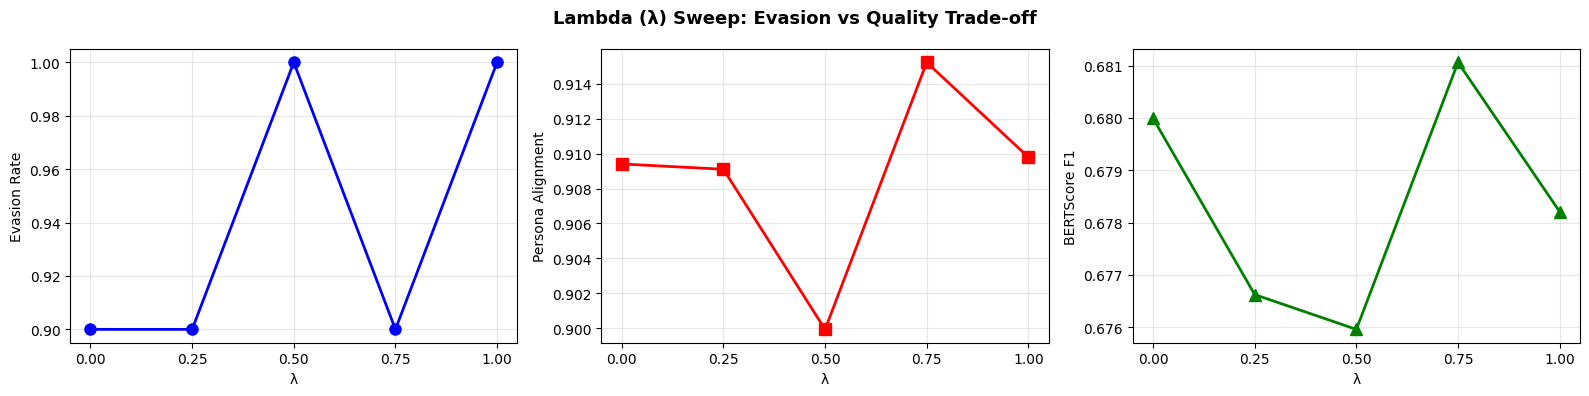

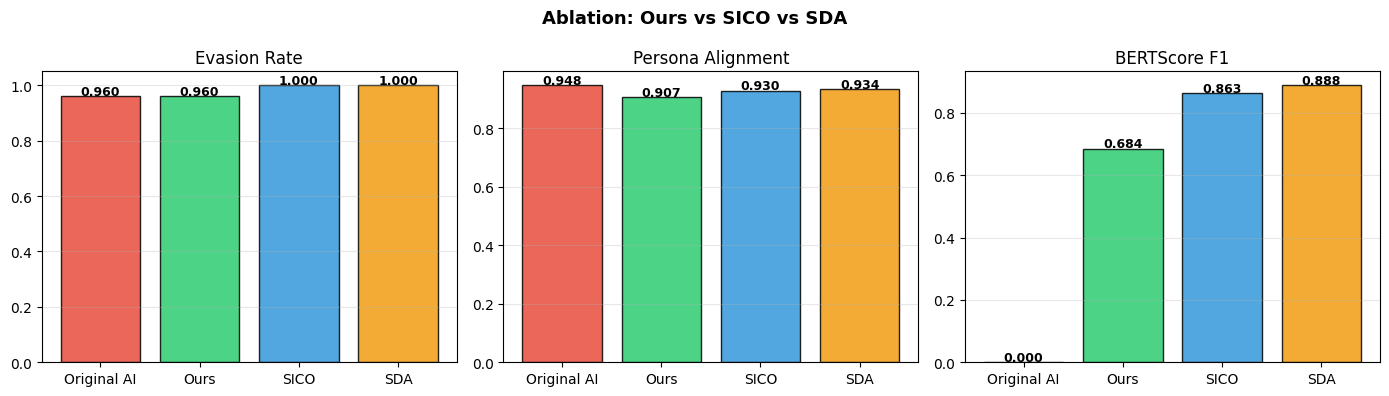


Saved: results_*.csv, lambda_sweep.csv, evaluation_summary.csv


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# --- Cell 16: 6-Metric Summary Table ---
def summarize(results_dict):
    rows = {}
    for method, items in results_dict.items():
        rows[method] = {
            'Evasion Rate  (↑)':     f"{np.mean([r['evaded'] for r in items]):.2%}",
            'Avg AI Score  (↓)':     f"{np.mean([r['ai_score'] for r in items]):.4f}",
            'BERTScore F1  (↑)':     f"{np.mean([r.get('bertscore',0) for r in items]):.4f}",
            'Perplexity    (↓)':     f"{np.mean([r['ppl'] for r in items]):.1f}",
            'FK Grade      (lower=easier)': f"{np.mean([r['fk_grade'] for r in items]):.2f}",
            'Persona Align (↑)':     f"{np.mean([r['persona_alignment'] for r in items]):.4f}",
            'KL-Div        (↓)':     f"{np.mean([r['kl_div'] for r in items]):.4f}",
        }
    return pd.DataFrame(rows).T

summary_df = summarize(results)
print('\n' + '='*65)
print('6-METRIC EVALUATION RESULTS')
print('='*65)
print(summary_df.to_string())
print('='*65)

# --- Cell 17: AUC Reduction ---
# We compute human scores once to compare against all AI methods
human_scores = [get_ai_score(t) for t in tqdm(human_df.head(N_EVAL)['answer'], desc='Human AI scores')]
print('\n--- AUC Reduction ---')
for method in ['original', 'ours', 'sico', 'sda']:
    ai_scores = [r['ai_score'] for r in results[method]]
    y_true    = [0]*len(human_scores) + [1]*len(ai_scores)
    y_scores  = human_scores + ai_scores
    auc = roc_auc_score(y_true, y_scores)
    print(f'  {method.upper():10s}: AUC = {auc:.4f}')

# --- Cell 18: Lambda (λ) Sweep ---
# Note: This will take a few minutes as it runs new rewrites
LAMBDA_VALUES = [0.0, 0.25, 0.5, 0.75, 1.0]
N_SWEEP = 20
sweep_set = ai_df.head(N_SWEEP).reset_index(drop=True)
lambda_rows = []

print(f'\nLambda sweep on {N_SWEEP} samples...')
for lam in LAMBDA_VALUES:
    evasions, alignments, rewrites, originals = [], [], [], []
    for _, row in sweep_set.iterrows():
        # Running our_method for the sweep
        txt, _ = our_method(row['answer'], row['question'], pool_df, n_candidates=3, lam=lam)
        ai_s   = get_ai_score(txt)
        feats  = extract_stylometrics(txt)
        align, _ = persona_alignment_score(feats, persona_profile)
        
        evasions.append(ai_s < THRESHOLD)
        alignments.append(align)
        rewrites.append(txt)
        originals.append(row['answer'])
    
    # Compute BERTScore on CPU for the sweep results
    bs = compute_bertscore(rewrites, originals)
    lambda_rows.append({
        'lambda': lam, 
        'evasion_rate': np.mean(evasions),
        'persona_alignment': np.mean(alignments), 
        'bertscore': bs
    })
    print(f'  λ={lam} → Evasion={np.mean(evasions):.2%}  PersonaAlign={np.mean(alignments):.4f}  BERTScore={bs:.4f}')

lambda_df = pd.DataFrame(lambda_rows)

# --- Cell 19: Plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Lambda (λ) Sweep: Evasion vs Quality Trade-off', fontsize=13, fontweight='bold')
lams = lambda_df['lambda'].tolist()
specs = [
    ('evasion_rate',       'Evasion Rate',       'bo-'),
    ('persona_alignment',  'Persona Alignment',  'rs-'),
    ('bertscore',          'BERTScore F1',       'g^-'),
]
for ax, (col, ylabel, style) in zip(axes, specs):
    ax.plot(lams, lambda_df[col], style, linewidth=2, markersize=8)
    ax.set_xlabel('λ'); ax.set_ylabel(ylabel)
    ax.set_xticks(lams); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Ablation bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Ablation: Ours vs SICO vs SDA', fontsize=13, fontweight='bold')
methods = ['original', 'ours', 'sico', 'sda']
labels  = ['Original AI', 'Ours', 'SICO', 'SDA']
colors  = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
metric_fns = [
    ('Evasion Rate',       lambda items: np.mean([r['evaded'] for r in items])),
    ('Persona Alignment',  lambda items: np.mean([r['persona_alignment'] for r in items])),
    ('BERTScore F1',       lambda items: np.mean([r.get('bertscore', 0) for r in items])),
]
for ax, (name, fn) in zip(axes, metric_fns):
    vals = [fn(results[m]) for m in methods]
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='black')
    ax.set_title(name); ax.grid(True, axis='y', alpha=0.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height()+0.005,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Cell 20: Save Results ---
for method in ['original', 'ours', 'sico', 'sda']:
    pd.DataFrame(results[method]).to_csv(f'results_{method}.csv', index=False)
lambda_df.to_csv('lambda_sweep.csv', index=False)
summary_df.to_csv('evaluation_summary.csv')
print('\nSaved: results_*.csv, lambda_sweep.csv, evaluation_summary.csv')